# Activity 1. Data Loading and Preprocessing

## Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

data = pd.read_csv(
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    encoding="iso8859-1"
)

## Explore the Dataset:

### a) Display the data shape

In [2]:
data.shape

(7043, 21)

### b) Show the column names

In [3]:
data.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### c) Show first 5 rows

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### d) Check for missing values and handle appropriately

In [5]:
print("Missing values per column before processing:")
data[data.isna().any(axis=1)]

Missing values per column before processing:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [6]:
# TotalCharges is known to have some non-numeric values like spaces – convert to numeric
if 'TotalCharges' in data.columns:
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

print("Missing values per column after converting TotalCharges to numeric:")
data[data.isna().any(axis=1)]

Missing values per column after converting TotalCharges to numeric:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
data = data.dropna()
print("Shape after dropping rows with missing values:", data.shape)

Shape after dropping rows with missing values: (7032, 21)


## Analyze Class Distribution

### a) Examine the distribution of the target variable (Churn) and calculate the class counts and percentages.

In [8]:
class_counts = data['Churn'].value_counts()
print("Class counts:\n", class_counts)


class_percentages = data['Churn'].value_counts(normalize=True) * 100
print("\nClass percentages (%):\n", class_percentages.round(2))

Class counts:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64

Class percentages (%):
 Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


### b) Create a bar chart to visualize the class distribution.

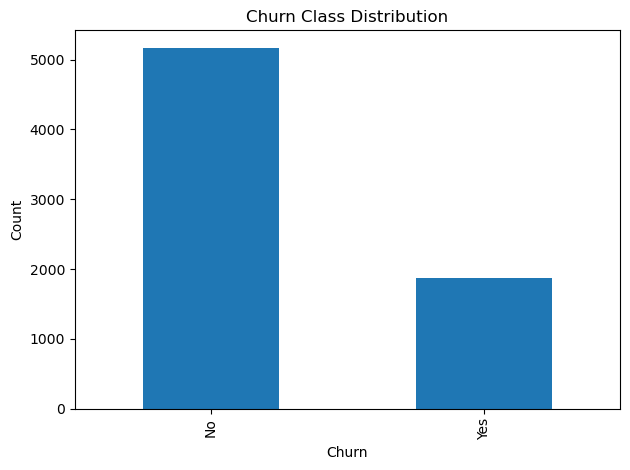

In [9]:
plt.figure()
class_counts.plot(kind='bar')
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Activity 2. Data Processing

## Feature Preprocessing

### a) Encode categorical variables using appropriate techniques

In [10]:
y = data['Churn'].map({'No': 0, 'Yes': 1})
X = data.drop(['customerID', 'Churn'], axis=1)

numeric_features = X.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### b) Scale numerical features using `StandardScaler`

In [11]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### c) Split the data into training (80%) and testing (20%) sets using `random_state=42`

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Fit the preprocessor on training data and transform
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Train shape: (5625, 19)  Test shape: (1407, 19)
Processed train shape: (5625, 45)
Processed test shape: (1407, 45)


## Baseline Model Performance

### a) Train a logistic regression model on the original (imbalanced) training data

In [13]:
baseline_log_reg = LogisticRegression(max_iter=1000)
baseline_log_reg.fit(X_train_processed, y_train)

y_pred_baseline = baseline_log_reg.predict(X_test_processed)

### b) Evaluate the model on the test set using confusion matrix

In [14]:
# Confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
print("Confusion Matrix (Baseline Logistic Regression):\n", cm_baseline)

# Classification report
print("\nClassification Report (Baseline Logistic Regression):")
print(classification_report(y_test, y_pred_baseline))

# Accuracy
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print("Baseline accuracy:", round(acc_baseline, 4))

Confusion Matrix (Baseline Logistic Regression):
 [[917 116]
 [160 214]]

Classification Report (Baseline Logistic Regression):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Baseline accuracy: 0.8038


### c) Analysis: Which class is being predicted poorly? Why might accuracy be misleading for this dataset?

> The class being predicted poorly is the **churn class (Churn = 1, “Yes”)**.
> 
> From the confusion matrix and report, the model has much lower recall and F1-score for class 1 compared to class 0, meaning many actual churners are incorrectly predicted as non-churners.
> 
> Accuracy is misleading for this dataset because the classes are **imbalanced**: there are many more non-churn customers (class 0) than churn customers (class 1). A model can achieve a high accuracy mainly by correctly predicting the majority class, even if it performs poorly on the minority class. In a churn prediction problem, we especially care about correctly identifying churners, so metrics like **precision, recall, and F1-score for the churn class** are more informative than overall accuracy.


# Activity 3. SMOTE for Class Balance

## Apply SMOTE

### a) Import SMOTE from imblearn and apply it to the training data only

In [15]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

### b) Compare the class distribution before and after SMOTE

In [16]:
# Check original class distribution in training data
y_train_counts = y_train.value_counts()
print("Original training class distribution:\n", y_train_counts)

# New class distribution after SMOTE
y_train_smote_counts = pd.Series(y_train_smote).value_counts()
print("\nTraining class distribution after SMOTE:\n", y_train_smote_counts)

print()
print("Number of samples before SMOTE:", X_train_processed.shape[0])
print("Number of samples after SMOTE:", X_train_smote.shape[0])

Original training class distribution:
 Churn
0    4130
1    1495
Name: count, dtype: int64

Training class distribution after SMOTE:
 Churn
0    4130
1    4130
Name: count, dtype: int64

Number of samples before SMOTE: 5625
Number of samples after SMOTE: 8260


### c) Explain why SMOTE should only be applied to training data

> SMOTE is applied **only** to the training data so that the test set remains an unbiased estimate of real-world performance. 
> 
> If SMOTE were applied to the test data, synthetic samples would leak information from the training process into evaluation, leading to overly optimistic performance estimates.

## Model Comparison

### a) Train a logistic regression model on the SMOTE-balanced data

In [17]:
log_reg_smote = LogisticRegression(max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### b) Evaluate and compare the performance with the baseline model

In [18]:
# Predictions
y_pred_smote = log_reg_smote.predict(X_test_processed)

# Confusion matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (Logistic Regression + SMOTE):\n", cm_smote)

# Classification report
print("\nClassification Report (Logistic Regression + SMOTE):")
print(classification_report(y_test, y_pred_smote))

# Accuracy
acc_smote = accuracy_score(y_test, y_pred_smote)
print("Accuracy with SMOTE:", round(acc_smote, 4))

Confusion Matrix (Logistic Regression + SMOTE):
 [[738 295]
 [ 83 291]]

Classification Report (Logistic Regression + SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

Accuracy with SMOTE: 0.7313


### c) Discuss the trade-offs between precision and recall. Which approach is better for customer churn prediction?

> **Trade-off:**
> * After using **SMOTE**, the model:
>   * **Recall for churn (1) increases** from 0.57 → **0.78**
>   * **Precision for churn (1) decreases** from 0.65 → **0.50**
>   * Overall **accuracy drops** from about 0.80 → **0.73**, because we are making more mistakes on the non-churn class.
> 
> In a churn problem, **missing a real churner (false negative)** is usually more costly than mistakenly treating a non-churner as a churner (false positive), because losing a customer means losing future revenue. 
> 
> Therefore, we usually **prefer higher recall for the churn class**, even if precision and overall accuracy drop.
> 
> **So, the SMOTE-based model is better for customer churn prediction**

# Activity 4. Linear vs Non-Linear Classifiers
## Linear Classifiers
Train and evaluate the following linear classifiers on SMOTE-balanced data:
### a) Linear SVM (SVC(kernel='linear'))

In [19]:
linear_svm = SVC(kernel='linear', probability=True, random_state=42)
linear_svm.fit(X_train_smote, y_train_smote)
y_pred_linear_svm = linear_svm.predict(X_test_processed)

### b) Gaussian Naive Bayes

In [20]:
nb = GaussianNB()
nb.fit(X_train_smote.toarray() if hasattr(
    X_train_smote, 'toarray') else X_train_smote, y_train_smote)
X_test_nb = X_test_processed.toarray() if hasattr(
    X_test_processed, 'toarray') else X_test_processed
y_pred_nb = nb.predict(X_test_nb)

## Non-linear Classifiers

Train and evaluate the following non-linear classifiers on SMOTE-balanced data:

### a) Random Forest (n_estimators=100)

In [21]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test_processed)

### b) SVM with RBF kernel (SVC(kernel='rbf'))

In [22]:
# SVM with RBF kernel
rbf_svm = SVC(kernel='rbf', probability=True, random_state=42)
rbf_svm.fit(X_train_smote, y_train_smote)
y_pred_rbf_svm = rbf_svm.predict(X_test_processed)

### c) Decision Tree (max_depth=10)

In [23]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_smote, y_train_smote)
y_pred_dt = dt.predict(X_test_processed)

## Model Comparison
### a) Create a comparison table showing accuracy, precision, recall, and F1-score for all classifiers.

In [24]:
models = {
    'LogReg_SMOTE': (log_reg_smote, y_pred_smote),
    'Linear_SVM': (linear_svm, y_pred_linear_svm),
    'GaussianNB': (nb, y_pred_nb),
    'RandomForest': (rf, y_pred_rf),
    'RBF_SVM': (rbf_svm, y_pred_rbf_svm),
    'DecisionTree': (dt, y_pred_dt)
}

rows = []
for name, (model, y_pred) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rows.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

results_df = pd.DataFrame(rows)
results_df = results_df.set_index('Model')
results_df.round(4)

,Accuracy,Precision,Recall,F1-score
Model,,,,
LogReg_SMOTE,0.7313,0.4966,0.7781,0.6062
Linear_SVM,0.7143,0.4776,0.7995,0.5980
GaussianNB,0.6930,0.4566,0.8155,0.5854
RandomForest,0.7754,0.5797,0.5642,0.5718
RBF_SVM,0.7534,0.5262,0.7246,0.6097
DecisionTree,0.7413,0.5098,0.6925,0.5873


### b) Generate ROC curves for all classifiers on the same plot.

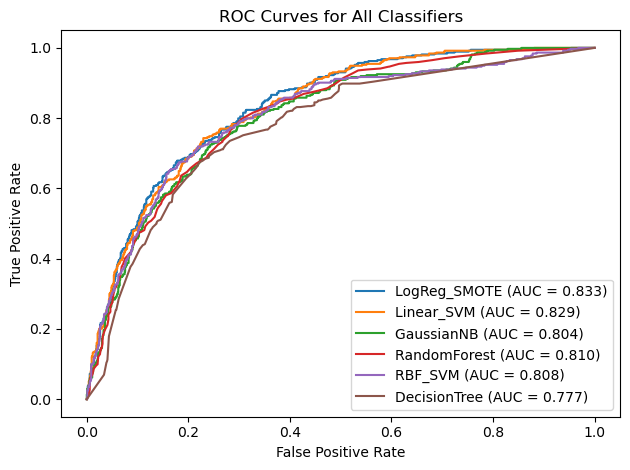

In [25]:
plt.figure()

for name, (model, y_pred) in models.items():
    if name == 'GaussianNB':
        y_score = model.predict_proba(X_test_nb)[:, 1]
    else:
        y_score = model.predict_proba(X_test_processed)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Classifiers')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Analysis
### a) Extract and display the top 10 most important features from the Random Forest model

In [26]:
# Get feature names from the preprocessor
cat_encoder = preprocess.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

rf_importances = rf.feature_importances_
rf_importances_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_importances
})

rf_top10 = rf_importances_df.sort_values(
    'importance', ascending=False).head(10)
print("Top 10 important features (Random Forest):")
rf_top10

Top 10 important features (Random Forest):


,feature,importance
1,tenure,0.109578
3,TotalCharges,0.106265
2,MonthlyCharges,0.096240
36,Contract_Month-to-month,0.076431
18,OnlineSecurity_No,0.054101
43,PaymentMethod_Electronic check,0.052174
27,TechSupport_No,0.043296
38,Contract_Two year,0.037691
16,InternetService_Fiber optic,0.025999
21,OnlineBackup_No,0.022260


### b) Analyze the coefficients from the Logistic Regression model

In [27]:
log_reg_coefs = log_reg_smote.coef_[0]
log_reg_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': log_reg_coefs
})
log_reg_df['abs_coefficient'] = log_reg_df['coefficient'].abs()

log_reg_top = log_reg_df.sort_values(
    'abs_coefficient', ascending=False).head(10)
print("Top 10 features by absolute coefficient (Logistic Regression + SMOTE):")
log_reg_top

Top 10 features by absolute coefficient (Logistic Regression + SMOTE):


,feature,coefficient,abs_coefficient
1,tenure,-1.418406,1.418406
38,Contract_Two year,-0.770045,0.770045
3,TotalCharges,0.762573,0.762573
2,MonthlyCharges,-0.743944,0.743944
36,Contract_Month-to-month,0.706088,0.706088
16,InternetService_Fiber optic,0.702559,0.702559
15,InternetService_DSL,-0.644957,0.644957
9,Dependents_Yes,-0.286615,0.286615
31,StreamingTV_No internet service,-0.273767,0.273767
28,TechSupport_No internet service,-0.273767,0.273767


### c) Based on performance metrics, select the best model.

> Best model is **RBF\_SVM**
> 
> * **RBF\_SVM** achieves:
>   * **High F1-score (0.6097)** → the best balance between precision and recall
>   * **Good accuracy (0.7534)**
>   * **Reasonable precision (0.5262)** and **high recall (0.7246)** for churners
> 
> For churn prediction, we want **high recall** (catch more real churners) but also not sacrifice precision too much.
> 
> So, **RBF\_SVM provides the best overall trade-off between accuracy, precision, recall, and F1-score**.